In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
      confusion_matrix, roc_auc_score)
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

os.chdir(r"C:\Users\imagatsya\Downloads\credit-risk\credit-risk-model")

X_train = pd.read_csv("outputs/X_train.csv")
X_test  = pd.read_csv("outputs/X_test.csv")
y_train = pd.read_csv("outputs/y_train.csv").squeeze()
y_test  = pd.read_csv("outputs/y_test.csv").squeeze()

print(f"Training: {X_train.shape}")
print(f"Testing : {X_test.shape}")

Training: (1076248, 22)
Testing : (269062, 22)


In [9]:
# ── MODEL 1: LOGISTIC REGRESSION ─────────────

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

print(f"Accuracy : {accuracy_score(y_test, lr_pred):.3f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, lr_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Training Logistic Regression...


Accuracy : 0.801
AUC-ROC  : 0.694

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.99      0.89    215350
           1       0.51      0.05      0.09     53712

    accuracy                           0.80    269062
   macro avg       0.66      0.52      0.49    269062
weighted avg       0.75      0.80      0.73    269062



In [10]:
# ── MODEL 2: RANDOM FOREST ───────────────────
# Builds 100 decision trees and combines them
# Better at catching defaulters than logistic regression

from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest... (may take 10-15 mins)")
rf = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    max_depth=10,        # limit depth to prevent overfitting
    class_weight='balanced',  # fix class imbalance
    random_state=42,
    n_jobs=-1            # use all CPU cores
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

print(f"Accuracy : {accuracy_score(y_test, rf_pred):.3f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, rf_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Training Random Forest... (may take 10-15 mins)
Accuracy : 0.638
AUC-ROC  : 0.712

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.63      0.74    215350
           1       0.31      0.68      0.43     53712

    accuracy                           0.64    269062
   macro avg       0.60      0.65      0.58    269062
weighted avg       0.77      0.64      0.67    269062



In [11]:
# ── MODEL 3: XGBOOST ─────────────────────────
# Most powerful model — industry standard
# scale_pos_weight fixes class imbalance

print("Training XGBoost...")

# ratio of non-defaulters to defaulters
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,  # fixes imbalance
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

print(f"Accuracy : {accuracy_score(y_test, xgb_pred):.3f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, xgb_prob):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

Training XGBoost...
Accuracy : 0.652
AUC-ROC  : 0.724

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.64      0.75    215350
           1       0.32      0.68      0.44     53712

    accuracy                           0.65    269062
   macro avg       0.61      0.66      0.59    269062
weighted avg       0.78      0.65      0.69    269062



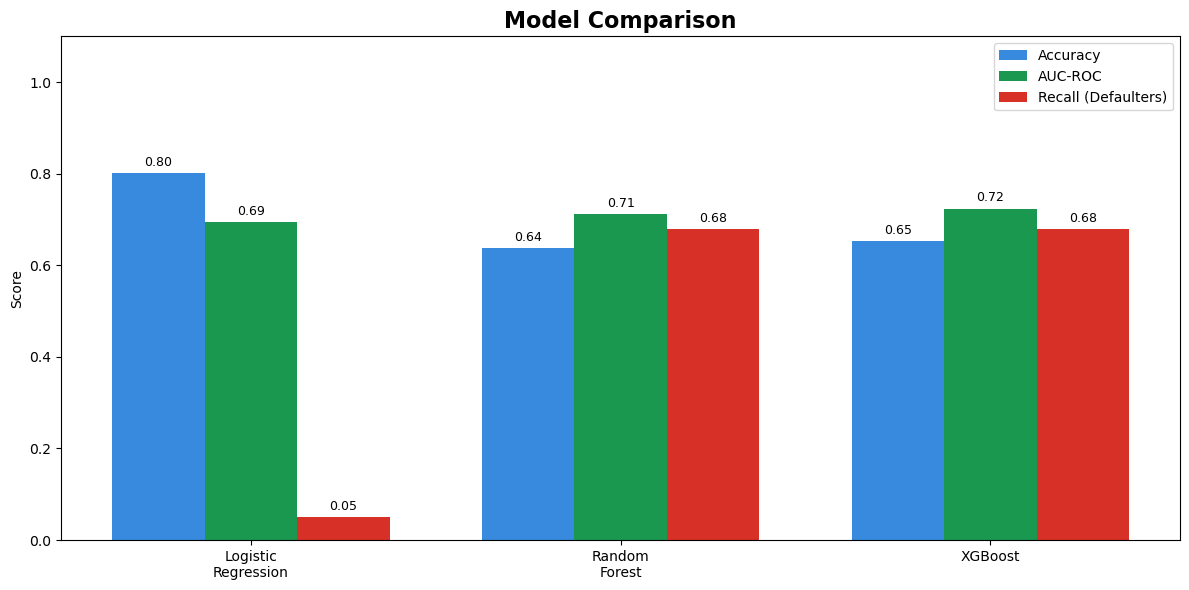

In [12]:
# ── MODEL COMPARISON CHART ───────────────────

models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
auc_scores = [0.694, 0.712, 0.724]
recall_scores = [0.05, 0.68, 0.68]
accuracy_scores = [0.801, 0.638, 0.652]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(x - width, accuracy_scores, width, label='Accuracy', color='#378ADD')
ax.bar(x, auc_scores, width, label='AUC-ROC', color='#1a9850')
ax.bar(x + width, recall_scores, width, label='Recall (Defaulters)', color='#d73027')

ax.set_title('Model Comparison', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.legend()
ax.set_ylim(0, 1.1)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('outputs/chart6_model_comparison.png', dpi=150)
plt.show()

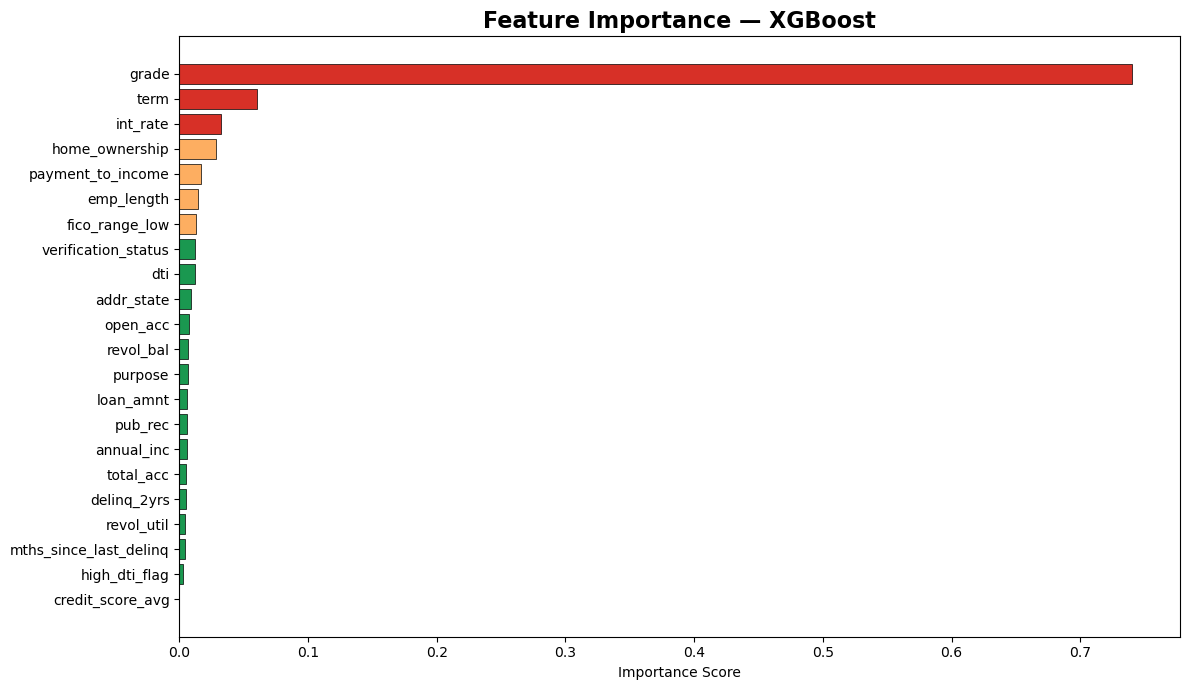

                   Feature  Importance
3                    grade    0.740514
1                     term    0.059980
2                 int_rate    0.032531
5           home_ownership    0.028761
19       payment_to_income    0.016604
4               emp_length    0.014258
12          fico_range_low    0.012992
7      verification_status    0.012373
10                     dti    0.012050
9               addr_state    0.009366
14                open_acc    0.007300
16               revol_bal    0.006867
8                  purpose    0.006836
0                loan_amnt    0.006105
15                 pub_rec    0.006018
6               annual_inc    0.005935
18               total_acc    0.005402
11             delinq_2yrs    0.004903
17              revol_util    0.004384
13  mths_since_last_delinq    0.004282
21           high_dti_flag    0.002539
20        credit_score_avg    0.000000


In [13]:
# ── FEATURE IMPORTANCE ───────────────────────
# Which features matter most to XGBoost?

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12,7))
colors = ['#d73027' if i < 3 else '#fdae61' if i < 7 else '#1a9850' 
          for i in range(len(feat_imp))]
plt.barh(feat_imp['Feature'], feat_imp['Importance'], 
         color=colors, edgecolor='black', linewidth=0.5)
plt.title('Feature Importance — XGBoost', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/chart7_feature_importance.png', dpi=150)
plt.show()

print(feat_imp)

In [14]:
# ── RISK SEGMENTATION ────────────────────────
# Convert probabilities to Low/Medium/High risk
# This is how banks actually use ML models

df_test = X_test.copy()
df_test['default_probability'] = xgb_prob
df_test['risk_category'] = pd.cut(
    df_test['default_probability'],
    bins=[0, 0.15, 0.35, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

print(df_test['risk_category'].value_counts())
print("\nDefault rate per segment:")
df_test['actual_default'] = y_test.values
print(df_test.groupby('risk_category', observed=True)['actual_default'].mean().mul(100).round(1))

risk_category
High Risk      182611
Medium Risk     69932
Low Risk        16519
Name: count, dtype: int64

Default rate per segment:
risk_category
Low Risk        2.8
Medium Risk     8.2
High Risk      26.0
Name: actual_default, dtype: float64


In [15]:
import joblib

joblib.dump(xgb_model, 'outputs/xgb_model.pkl')
joblib.dump(X_train.columns.tolist(), 'outputs/model_columns.pkl')

print("✓ Model saved!")

✓ Model saved!
